## Project Description

This project uses the **Congressional Voting Records (House Votes 84)** dataset from the UCI Machine Learning Repository. The dataset contains voting records from 435 members of the United States House of Representatives on 16 key legislative issues during 1984.

Each record includes the voting behavior of a congressman (Yes, No, or Unknown) and the corresponding political party affiliation (**Democrat** or **Republican**). The dataset provides an excellent opportunity to analyze voting patterns, identify relationships between political decisions and party affiliation, and develop machine learning models for classification tasks. [1](https://archive.ics.uci.edu/ml/datasets/Congressional+Voting+Records)[2](https://www.archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.names)

#### Objectives

- Analyze voting behavior patterns among members of Congress.
- Explore the relationship between legislative votes and political party affiliation.
- Identify the most influential voting issues for distinguishing Democrats from Republicans.
- Perform exploratory data analysis (EDA) to discover trends, distributions, and correlations within the dataset.
- Apply data preprocessing techniques to handle categorical values and missing data.
- Build and evaluate classification models to predict political party affiliation based on voting records.
- Demonstrate competencies in data analysis, feature selection, classification modeling, and machine learning fundamentals.

#### Target Variable

- **Party Affiliation (Class):**
  - Democrat
  - Republican

#### Skills Demonstrated

- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Categorical Data Encoding
- Missing Value Treatment
- Feature Importance Analysis
- Classification Modeling
- Data-Driven Decision Making

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

## Descripción de las variables del dataset

Funente de los datos:https://archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.data
| Variable | Descripción | Tipo |
|---|---|---|
| `party` | Afiliación política del congresista (demócrata o republicano) | Variable objetivo |
| `handicapped_infants` | Votación sobre subsidios a menores con discapacidad | Categórica |
| `water_project_cost_sharing` | Votación sobre financiamiento de proyectos de agua | Categórica |
| `adoption_of_the_budget_resolution` | Votación sobre resolución del presupuesto | Categórica |
| `physician_fee_freeze` | Votación sobre congelamiento de tarifas médicas | Categórica |
| `el_salvador_aid` | Votación sobre ayuda a El Salvador | Categórica |
| `religious_groups_in_schools` | Votación sobre participación religiosa en escuelas | Categórica |
| `anti_satellite_test_ban` | Votación sobre prohibición de pruebas anti-satélite | Categórica |
| `aid_to_nicaraguan_contras` | Votación sobre ayuda a los contras en Nicaragua | Categórica |
| `mx_missile` | Votación sobre el sistema de misiles MX | Categórica |
| `immigration` | Votación sobre políticas migratorias | Categórica |
| `synfuels_corporation_cutback` | Votación sobre reducción de financiamiento energético | Categórica |
| `education_spending` | Votación sobre gasto en educación | Categórica |
| `superfund_right_to_sue` | Votación sobre derecho a demandar por contaminación | Categórica |


In [ ]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.data"

columns = [
    "party",
    "handicapped_infants",
    "water_project_cost_sharing",
    "adoption_of_the_budget_resolution",
    "physician_fee_freeze",
    "el_salvador_aid",
    "religious_groups_in_schools",
    "anti_satellite_test_ban",
    "aid_to_nicaraguan_contras",
    "mx_missile",
    "immigration",
    "synfuels_corporation_cutback",
    "education_spending",
    "superfund_right_to_sue",
    "crime",
    "duty_free_exports",
    "export_administration_act_south_africa"
]
df = pd.read_csv(url, names=columns)
df.head()





,party,handicapped_infants,water_project_cost_sharing,adoption_of_the_budget_resolution,physician_fee_freeze,el_salvador_aid,religious_groups_in_schools,anti_satellite_test_ban,aid_to_nicaraguan_contras,mx_missile,immigration,synfuels_corporation_cutback,education_spending,superfund_right_to_sue,crime,duty_free_exports,export_administration_act_south_africa
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y


In [ ]:
# Reemplazar '?' por valores vacíos (NaN)
df = df.replace('?', pd.NA)

# Verificación
print(df.isnull().sum())

party                                       0
handicapped_infants                        12
water_project_cost_sharing                 48
adoption_of_the_budget_resolution          11
physician_fee_freeze                       11
el_salvador_aid                            15
religious_groups_in_schools                11
anti_satellite_test_ban                    14
aid_to_nicaraguan_contras                  15
mx_missile                                 22
immigration                                 7
synfuels_corporation_cutback               21
education_spending                         31
superfund_right_to_sue                     25
crime                                      17
duty_free_exports                          28
export_administration_act_south_africa    104
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   party                                   435 non-null    object
 1   handicapped_infants                     423 non-null    object
 2   water_project_cost_sharing              387 non-null    object
 3   adoption_of_the_budget_resolution       424 non-null    object
 4   physician_fee_freeze                    424 non-null    object
 5   el_salvador_aid                         420 non-null    object
 6   religious_groups_in_schools             424 non-null    object
 7   anti_satellite_test_ban                 421 non-null    object
 8   aid_to_nicaraguan_contras               420 non-null    object
 9   mx_missile                              413 non-null    object
 10  immigration                             428 non-null    object
 11  synfue

# Analysis

1. Missing values represented by the **'?'** symbol were converted to **null values (NaN)** using Pandas functions, allowing for proper identification and treatment during subsequent analysis.

2. All 17 columns have the **object** (text) data type. This is expected and appropriate because the dataset records votes as **y (yes)**, **n (no)**, or **NaN (missing/absent)**.

3. The **export_administration_act_south_africa** column is the most critical, with nearly **one out of every four records** containing missing values. This may indicate that many congressmen abstained from or were absent during that vote. The **water_project_cost_sharing** column also contains a notable proportion of missing values, accounting for approximately **11%** of the records.


In [ ]:

# Rellenar valores faltantes con la moda por columna
for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verificar que no queden nulos
print(df.isnull().sum())


party                                     0
handicapped_infants                       0
water_project_cost_sharing                0
adoption_of_the_budget_resolution         0
physician_fee_freeze                      0
el_salvador_aid                           0
religious_groups_in_schools               0
anti_satellite_test_ban                   0
aid_to_nicaraguan_contras                 0
mx_missile                                0
immigration                               0
synfuels_corporation_cutback              0
education_spending                        0
superfund_right_to_sue                    0
crime                                     0
duty_free_exports                         0
export_administration_act_south_africa    0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   party                                   435 non-null    object
 1   handicapped_infants                     435 non-null    object
 2   water_project_cost_sharing              435 non-null    object
 3   adoption_of_the_budget_resolution       435 non-null    object
 4   physician_fee_freeze                    435 non-null    object
 5   el_salvador_aid                         435 non-null    object
 6   religious_groups_in_schools             435 non-null    object
 7   anti_satellite_test_ban                 435 non-null    object
 8   aid_to_nicaraguan_contras               435 non-null    object
 9   mx_missile                              435 non-null    object
 10  immigration                             435 non-null    object
 11  synfue

# Explanation

Missing values were handled through **mode imputation**, considering the categorical nature of the dataset. This approach helped preserve data consistency and prevent information loss, ensuring proper preprocessing for the application of classification models.

/tmp/ipykernel_7476/895017587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


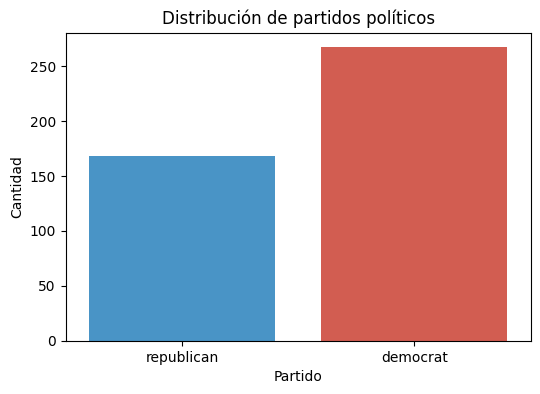

In [ ]:
#Distribución de la variable objetiv
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='party',
    palette=['#3498db', '#e74c3c']
)

plt.title('Distribución de partidos políticos')
plt.xlabel('Partido')
plt.ylabel('Cantidad')
plt.show()


# Analysis

1. The bar chart shows the distribution of congressmen by political party affiliation, revealing that the number of **Democrats** is higher than that of **Republicans**.

2. Approximately **270 Democrats** and **165 Republicans** are represented in the dataset, indicating a slight class imbalance.

3. This imbalance may affect the classification model, as it could bias predictions toward the majority class during training.

4. However, the distribution is not severely unbalanced, making the dataset still suitable for applying classification algorithms such as **Logistic Regression**.

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


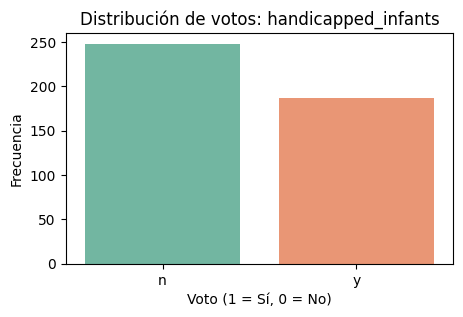

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


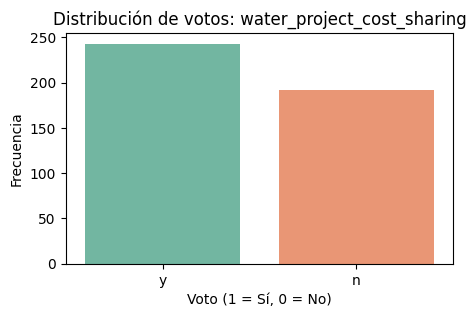

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


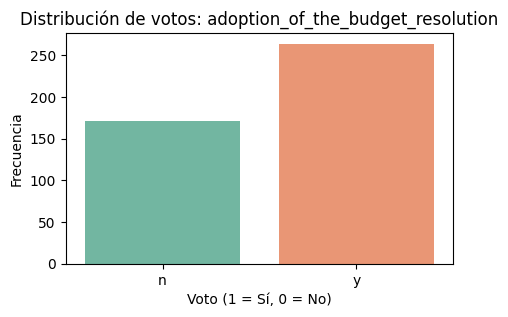

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


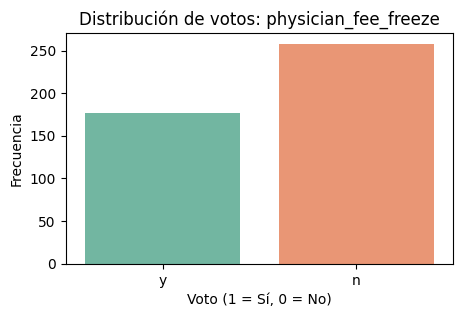

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


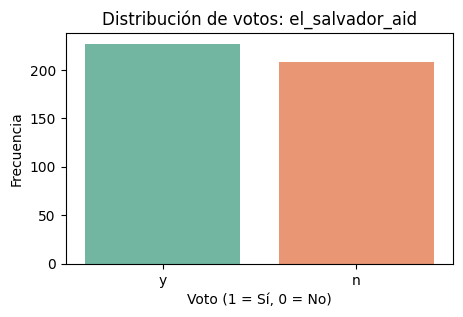

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


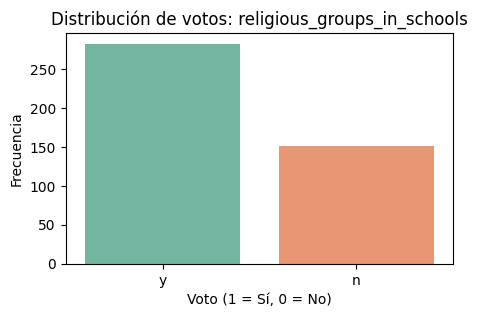

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


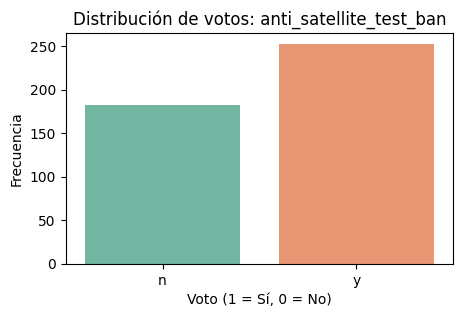

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


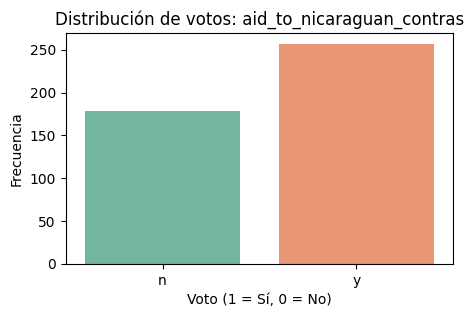

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


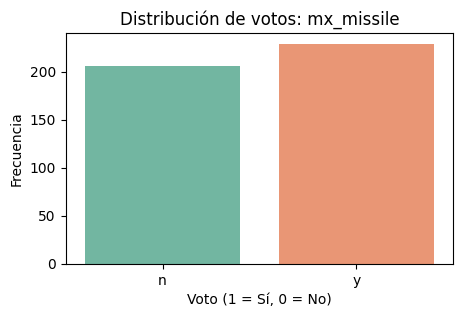

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


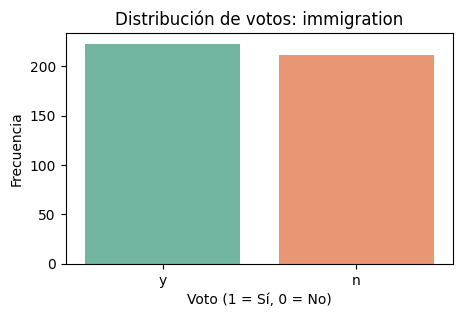

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


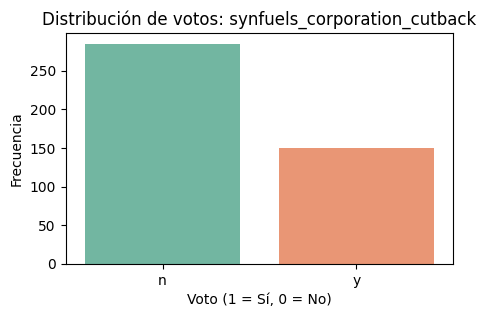

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


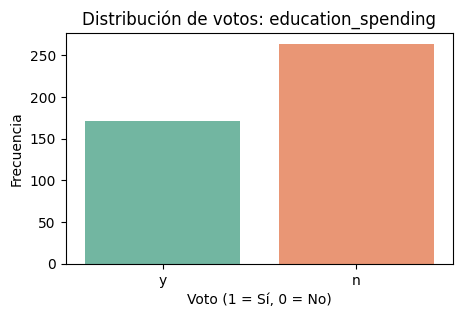

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


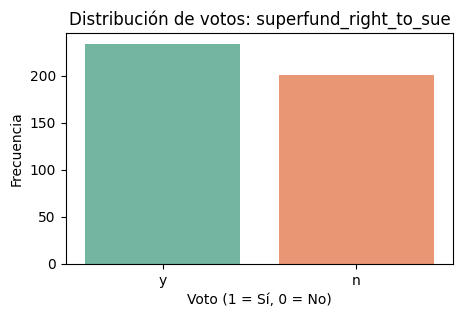

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


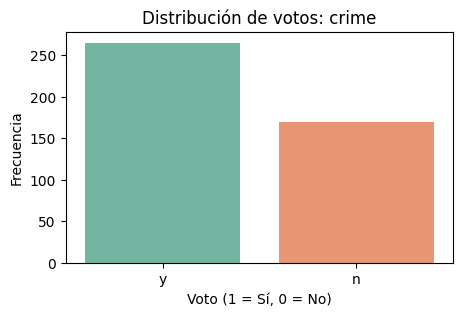

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


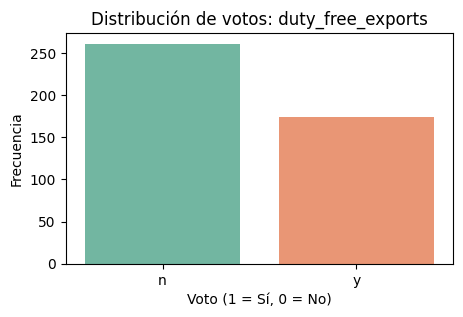

/tmp/ipykernel_7476/2225278808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


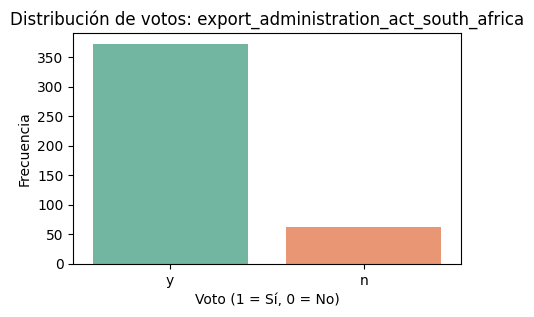

In [ ]:
#Distribución de votos
for col in df.columns[1:]:
    plt.figure(figsize=(5,3))

    sns.countplot(
        data=df,
        x=col,
        palette='Set2'
    )

    plt.title(f'Distribución de votos: {col}')
    plt.xlabel('Voto (1 = Sí, 0 = No)')
    plt.ylabel('Frecuencia')

    plt.show()


# Analysis

1. The vote distribution analysis shows that, for most legislative decisions, there are noticeable differences between the frequency of **"yes"** and **"no"** responses, revealing distinct voting behavior patterns.

2. Some variables are dominated by a particular voting outcome, suggesting a higher level of consensus on specific issues within Congress.

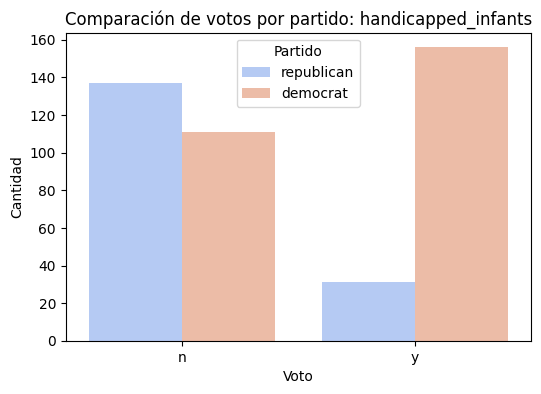

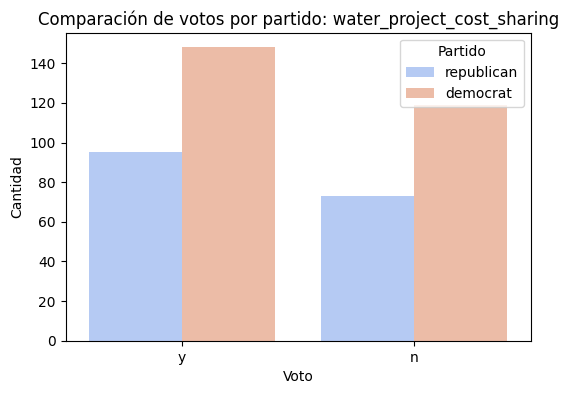

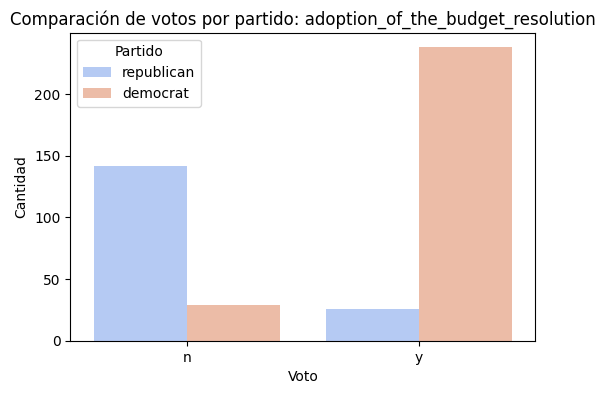

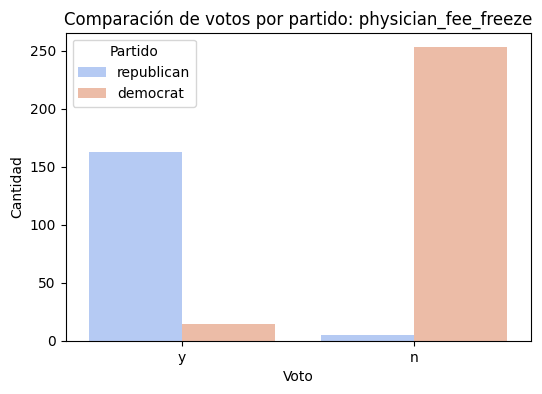

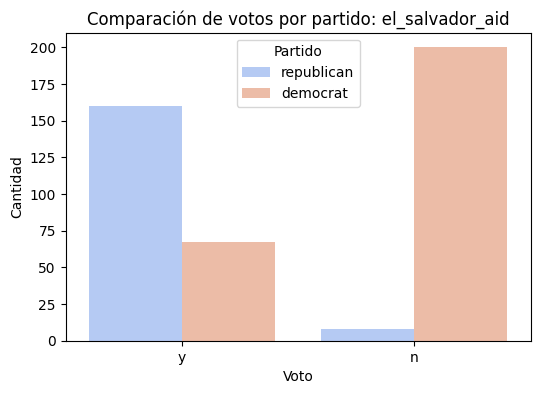

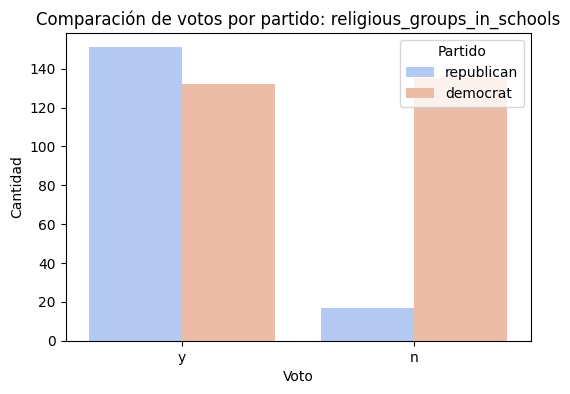

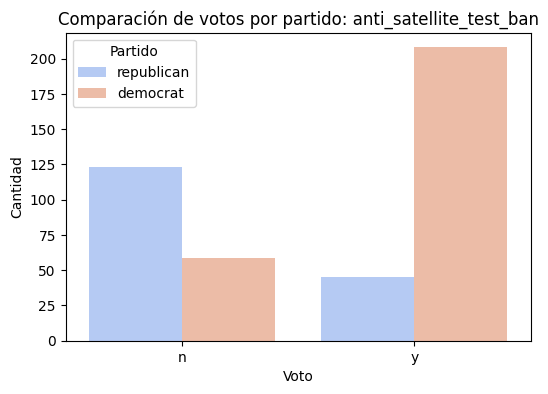

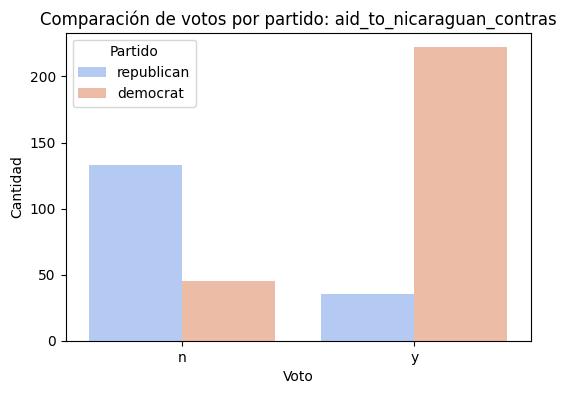

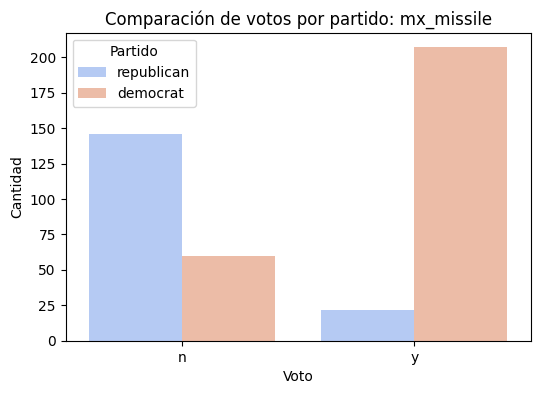

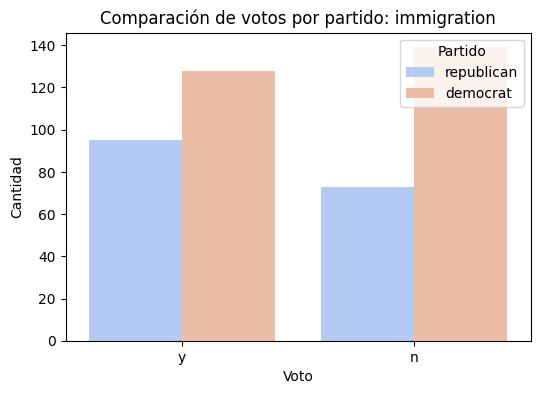

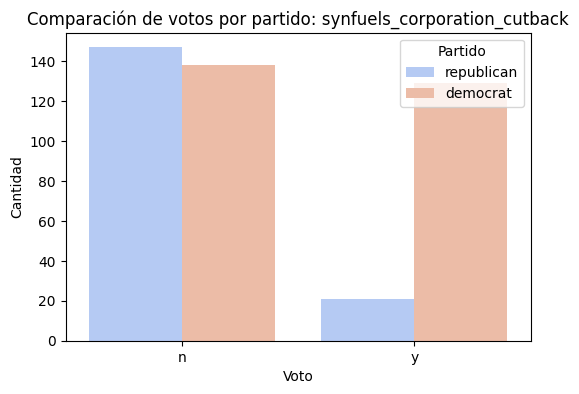

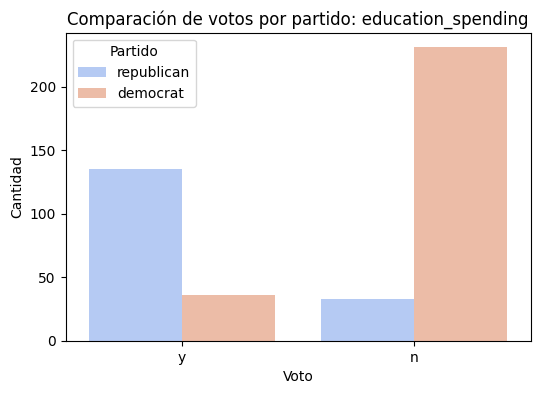

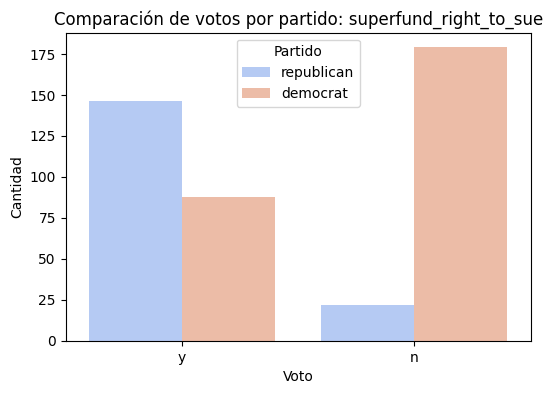

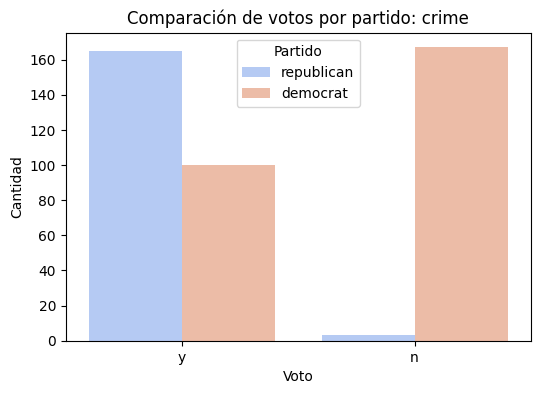

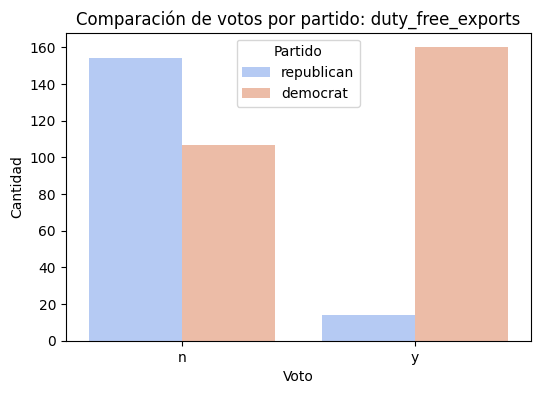

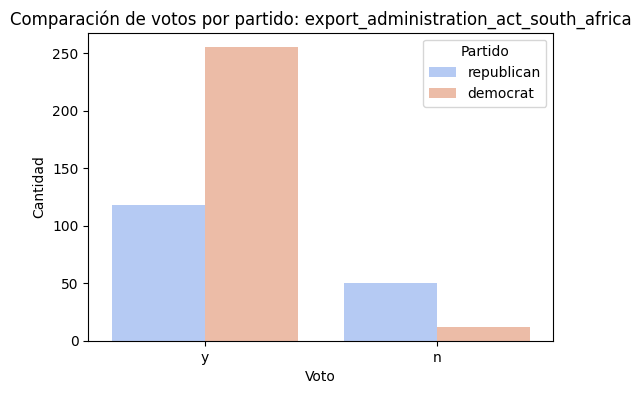

In [ ]:
#Comparación por partido
for col in df.columns[1:]:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        hue='party',
        palette='coolwarm'
    )

    plt.title(f'Comparación de votos por partido: {col}')
    plt.xlabel('Voto')
    plt.ylabel('Cantidad')

    plt.legend(title='Partido')
    plt.show()


# Analysis

1. The comparison by political party reveals clear differences in voting patterns between **Democrats** and **Republicans** across multiple legislative decisions.

2. These variations indicate that political preferences have a significant influence on voting behavior, making it possible to distinguish between parties using classification models.

/tmp/ipykernel_7476/4188895091.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df.replace({


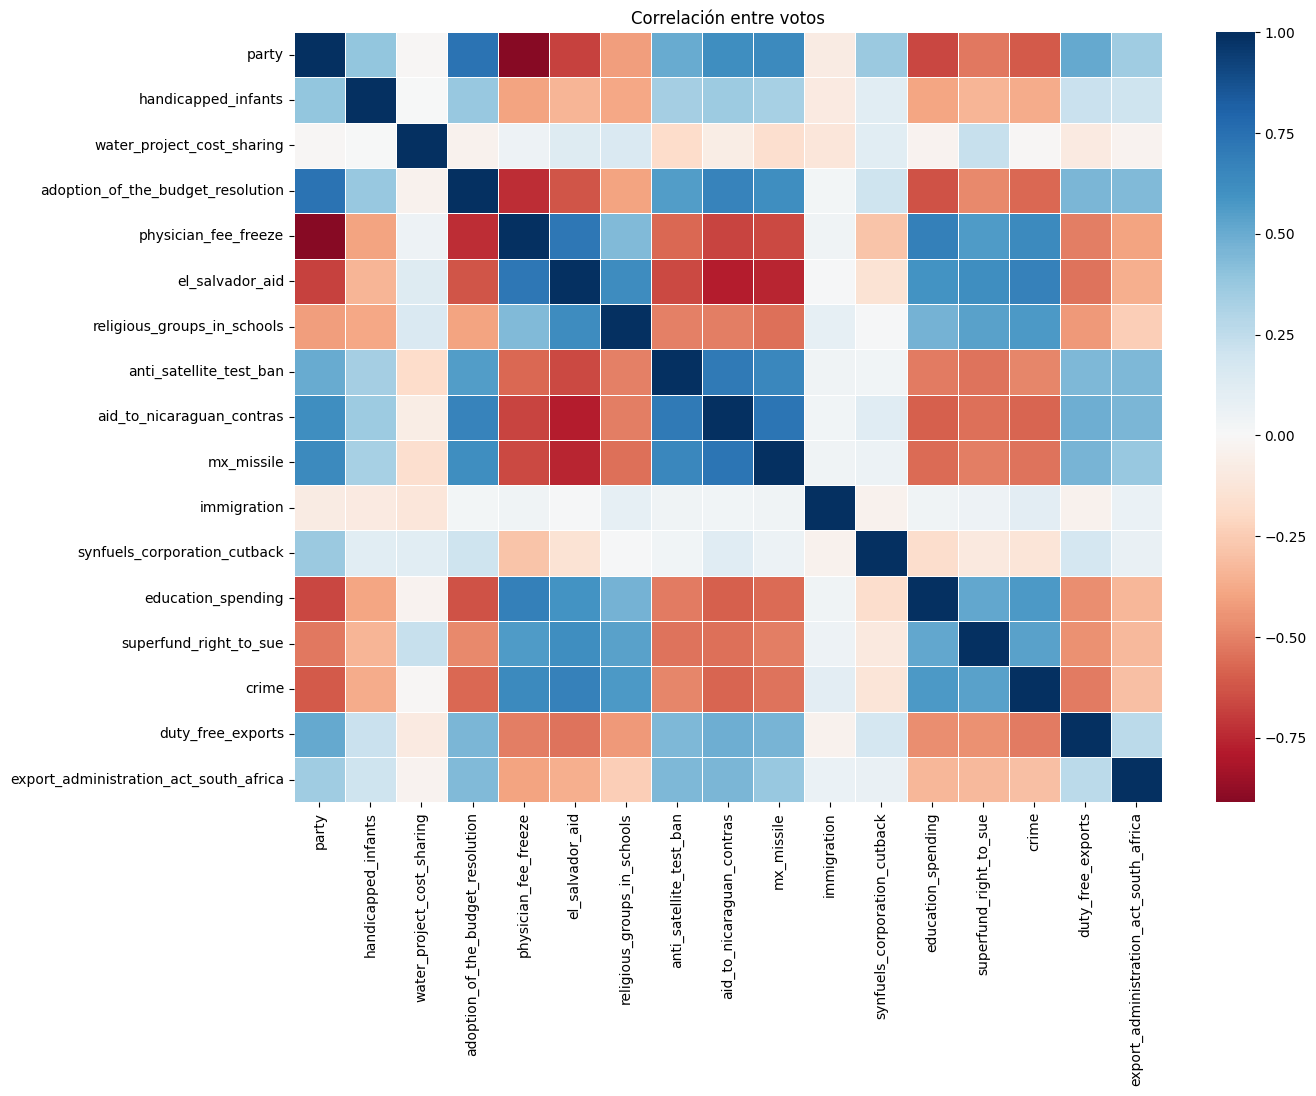

In [ ]:
#Mapa de calor
# Convertir TODAS las variables categóricas a numéricas
df_numeric = df.replace({
    'y': 1,
    'n': 0,
    'democrat': 1,
    'republican': 0
})

# Crear el heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df_numeric.corr(),
    cmap='RdBu',
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre votos")
plt.show()


# Analysis

1. The heatmap illustrates the relationships among the different voting variables, using a scale where **blue indicates a positive correlation** and **red indicates a negative correlation**.

2. Groups of variables with strong positive correlations can be observed, suggesting that certain votes tend to cluster together and reflect consistent ideological patterns.

3. Likewise, some variables exhibit notable negative correlations, indicating opposing positions on specific political issues, which is characteristic of differences between political parties.

4. In particular, the **party** variable shows meaningful correlations with several voting records, demonstrating that voting patterns provide a clear distinction between **Democrats** and **Republicans**.

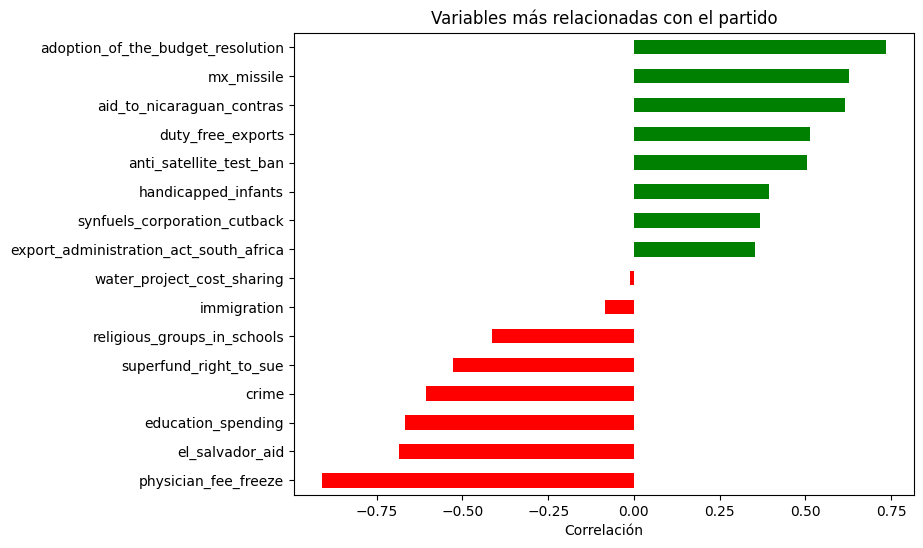

In [ ]:
#Relación con el partido
corr = df_numeric.corr()['party'].sort_values()

plt.figure(figsize=(8,6))

corr[:-1].plot(
    kind='barh',
    color=['red' if x < 0 else 'green' for x in corr[:-1]]
)

plt.title('Variables más relacionadas con el partido')
plt.xlabel('Correlación')
plt.show()


# Analysis

1. The chart shows variables with strong positive correlations (**green bars**) and negative correlations (**red bars**) with the **party** variable, indicating that certain votes are strongly associated with a specific political affiliation.

2. The results highlight that some legislative decisions are highly influential in distinguishing **Democrats** from **Republicans**, making them key features for building predictive models such as **Logistic Regression**.